# Ontario Highway Network Analysis

This notebook walks through the key analysis steps to identify potential corridors or hubs of interest for shared charging on Ontario's road network based on survey data.

Looking for an Overlap between the following attributes:

- Locations where we expect trucks to have Low SOC \(min SOC\) &  \-\-\> routes that we are going to receive are majorly based on diesel

- Amount of traffic \(volume of freight flow\)

- Frequency Dwell Times

- Where is there expected to be public support for EV class 7\-8 charging hubs? Forecast of where any future hubs will be built

- Commercial Electricity Rates \(Alectra utilities & Toronto Hydro rates\)

General considerations

- Need to consider that we are making a corridor, not a hub

- Existing infrastructure that we can interconnect to: enough space for truck entry and parking

Project level considerations:

- Capacity upgrades\.\.\. regional power generation capacity to supply this load\. Might save time in project development

Output: 3\-4 ideal locations in the GTHA \(a km range circle\)


Postal code inputs to add from survey

General FSA, rest stops, and preferences of hubs

## 0. Install Required Packages

If you haven't already, install the required packages using pip:

In [21]:
import subprocess
import sys

# Install required packages
packages = [
    'geopandas',
    'pandas',
    'numpy',
    'matplotlib',
    'shapely',
    
]

print("Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    print(f"✓ {package} installed")

print("\n✓ All required packages installed successfully")

Installing required packages...
✓ geopandas installed
✓ pandas installed
✓ numpy installed
✓ matplotlib installed
✓ shapely installed

✓ All required packages installed successfully


## 0.5 Download Data Files

Download required GeoJSON files if they don't already exist in the data directory.

In [22]:
import os
import subprocess

# Create data directory if it doesn't exist
data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)

# Define files to download
files_to_download = {
    'Ontario_Provincial_Boundary.geojson': 'https://hub.arcgis.com/api/v3/datasets/337b896c7862411ba365159b4cd9c8c7_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1',
    'Value_of_Goods_2016_-3795296180828259022.geojson': 'https://stg-arcgisazurecdataprod.az.arcgis.com/exportfiles-4893-6785/Value_of_Goods_2016_-3795296180828259022.geojson?sv=2025-05-05&st=2026-01-14T01%3A47%3A18Z&se=2026-01-14T02%3A52%3A18Z&sr=c&sp=r&sig=Euk7L0NNLSS019VXoLRRlVk%2BTQoPTJJ%2Bc%2FFW3EvOAw4%3D'
}

print("Checking data files...")
for filename, url in files_to_download.items():
    filepath = os.path.join(data_dir, filename)
    
    if os.path.exists(filepath):
        file_size = os.path.getsize(filepath)
        print(f"✓ {filename} exists ({file_size:,} bytes)")
    else:
        print(f"⬇ Downloading {filename}...")
        try:
            subprocess.run(['curl', '-L', '-o', filepath, url], check=True, capture_output=True)
            file_size = os.path.getsize(filepath)
            print(f"  ✓ Downloaded {filename} ({file_size:,} bytes)")
        except subprocess.CalledProcessError as e:
            print(f"  ✗ Error downloading {filename}: {e}")
        except FileNotFoundError:
            print(f"  ✗ curl not found. Please install curl or download files manually.")

print("\n✓ Data file check complete")

Checking data files...
✓ Ontario_Provincial_Boundary.geojson exists (1,000,426 bytes)
✓ Value_of_Goods_2016_-3795296180828259022.geojson exists (15,366,648 bytes)

✓ Data file check complete


## 1. Import Libraries and Custom Modules

In [23]:
# Standard libraries
import sys
import json
import importlib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from pathlib import Path

# Add source directory to path for custom modules
sys.path.insert(0, '../source')

# Import and reload to pick up any code changes
import Highways
importlib.reload(Highways)

from Highways import (
    load_data,
    load_ontario_boundary,
    geojson_to_gdf,
    normalize_highway_name,
    get_highway_color,
    get_distinct_colors,
    create_pdf_map,
    create_weighted_pdf_map
)

print("✓ All libraries imported successfully (module reloaded)")

✓ All libraries imported successfully (module reloaded)


## 2. Load and Prepare Data

We'll load three main data sources:
1. **GeoJSON**: Road network with 13,981 segments across Ontario
2. **Target Highways CSV**: 14 highways identified in fleet survey
3. **Provincial Boundary**: Ontario boundary for context

In [24]:
# Define data paths
GEOJSON_PATH = "../data/Value_of_Goods_2016_-3795296180828259022.geojson"
HIGHWAYS_CSV_PATH = "../data/target_highways.csv"
ONTARIO_BOUNDARY_PATH = "../data/Ontario_Provincial_Boundary.geojson"

# Load all data using utility functions
print("Loading data...")
geojson_data, highways_df = load_data(GEOJSON_PATH, HIGHWAYS_CSV_PATH)
gdf_ontario = load_ontario_boundary(ONTARIO_BOUNDARY_PATH)

print(f"✓ GeoJSON loaded: {len(geojson_data['features'])} features")
print(f"✓ Target highways loaded: {len(highways_df)} highways")
print(f"✓ Ontario boundary loaded")

# Convert to GeoDataFrames
print("\nConverting to GeoDataFrames...")
gdf_all = geojson_to_gdf(geojson_data)
gdf_targets = geojson_to_gdf(geojson_data, highways_df, filter_targets=True)

# Summary
print(f"✓ All road segments: {len(gdf_all)}")
print(f"✓ Target highway segments: {len(gdf_targets)}")
print(f"✓ Target highways included: {sorted(gdf_targets['matched_highway'].unique())}")
print("\nTarget segment counts (by matched_highway):")
print(gdf_targets['matched_highway'].value_counts().sort_index())

Loading data...
✓ GeoJSON loaded: 13981 features
✓ Target highways loaded: 15 highways
✓ Ontario boundary loaded

Converting to GeoDataFrames...
✓ All road segments: 13981
✓ Target highway segments: 5245
✓ Target highways included: ['11', '17', '400', '401', '402', '403', '410', '416', '417', '427', '69', '7', '8', '85', 'QEW']

Target segment counts (by matched_highway):
matched_highway
11      885
17      474
400     232
401    1014
402      82
403     202
410      54
416      57
417     244
427      98
69       79
7      1200
8       392
85       38
QEW     194
Name: count, dtype: int64


## 3. Initial Data Exploration

In [25]:
# Display target highways table
print("=" * 60)
print("TARGET HIGHWAYS FROM SURVEY")
print("=" * 60)
print(highways_df.to_string(index=False))
print()

# Analyze survey mention frequency
count_distribution = highways_df['count'].value_counts().sort_index(ascending=False)
print("\nSurvey Mention Frequency Distribution:")
for count in sorted(count_distribution.index, reverse=True):
    color_name = {1: 'Red', 2: 'Orange', 3: 'Green'}.get(count, 'Other')
    num_highways = count_distribution[count]
    print(f"  Count {count} ({color_name}): {num_highways} highway(s)")

TARGET HIGHWAYS FROM SURVEY
highway  count
      7      1
      8      1
     11      1
     17      1
     69      1
     85      1
    400      2
    401      3
    402      1
    403      2
    410      1
    416      1
    417      1
    427      1
    QEW      2


Survey Mention Frequency Distribution:
  Count 3 (Green): 1 highway(s)
  Count 2 (Orange): 3 highway(s)
  Count 1 (Red): 11 highway(s)


In [26]:
# Analyze road network attributes
print("\n" + "=" * 60)
print("ROAD NETWORK STATISTICS")
print("=" * 60)

print(f"\nBase Network (all roads):")
print(f"  Total segments: {len(gdf_all):,}")
print(f"  CRS: {gdf_all.crs}")

print(f"\nTarget Network (filtered highways):")
print(f"  Total segments: {len(gdf_targets):,}")
print(f"  Unique highways: {gdf_targets['matched_highway'].nunique()}")

# Check available attributes for weighting
weight_columns = ['AADTT16', 'VOG_WGT', 'VOG16']
print(f"\nAvailable weight attributes:")
for col in weight_columns:
    if col in gdf_targets.columns:
        valid_count = gdf_targets[col].notna().sum()
        if valid_count > 0:
            print(f"  {col}: {valid_count:,} segments with data")
            print(f"    - Min: {gdf_targets[col].min():.2f}")
            print(f"    - Max: {gdf_targets[col].max():.2f}")
            print(f"    - Mean: {gdf_targets[col].mean():.2f}")
        else:
            print(f"  {col}: No data available")


ROAD NETWORK STATISTICS

Base Network (all roads):
  Total segments: 13,981
  CRS: None

Target Network (filtered highways):
  Total segments: 5,245
  Unique highways: 15

Available weight attributes:
  AADTT16: 5,245 segments with data
    - Min: 0.00
    - Max: 22223.00
    - Mean: 2906.38
  VOG_WGT: 5,245 segments with data
    - Min: 0.00
    - Max: 102038549.00
    - Mean: 16984585.56
  VOG16: 5,245 segments with data
    - Min: 0.00
    - Max: 360153000.00
    - Mean: 62715706.01


## 4. Map Generation - Basic Network View

Generate a map with target highways colored by survey mention frequency:
- **Red**: Mentioned 1 time
- **Orange**: Mentioned 2 times  
- **Green**: Mentioned 3 times

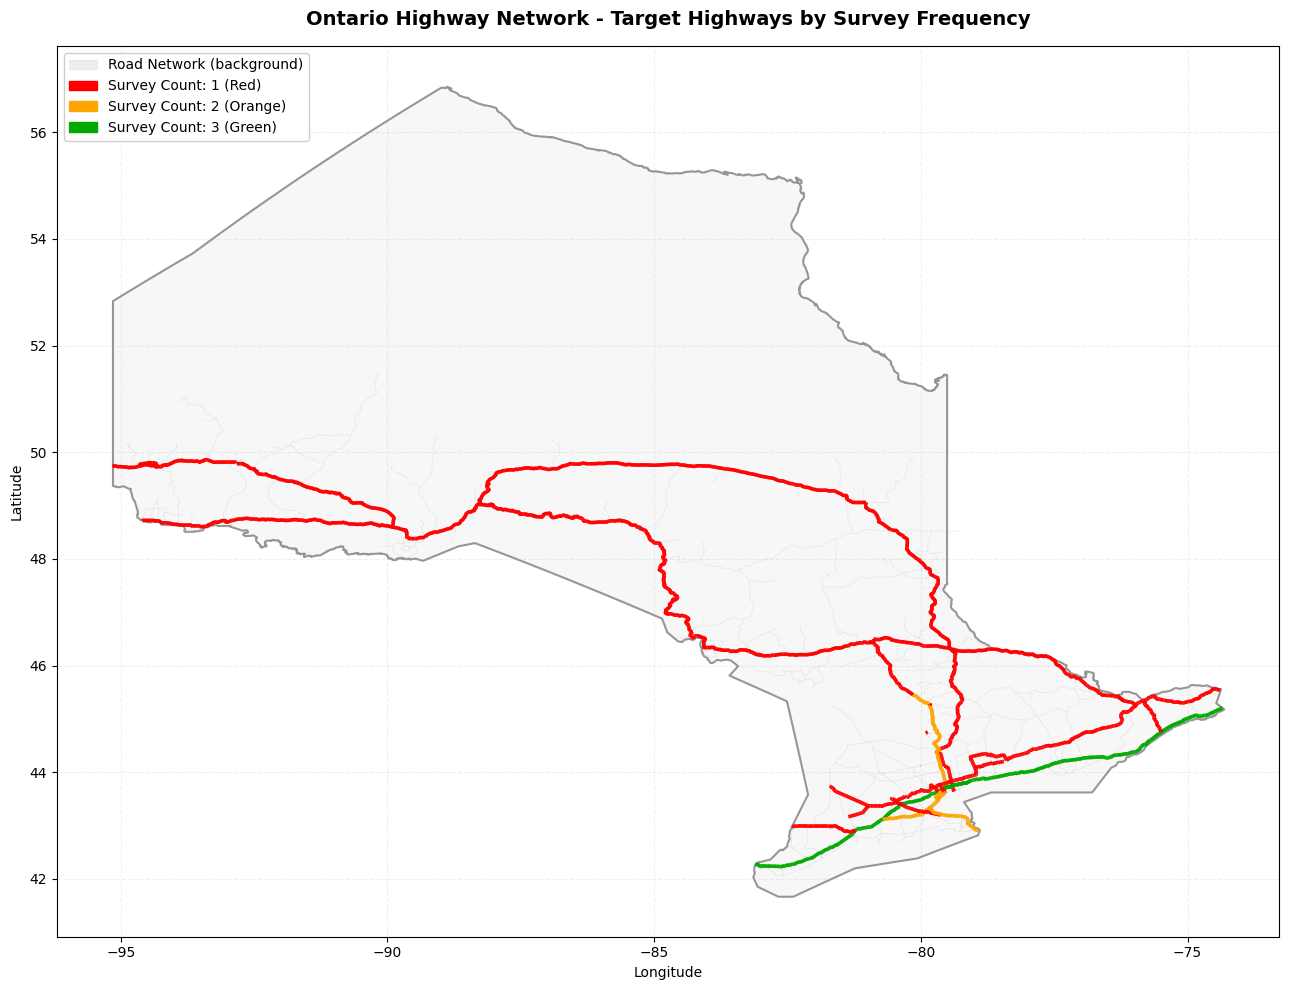

✓ Basic map visualization displayed


In [27]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "source").is_dir():
            return path
    return start


project_root = find_project_root(Path.cwd().resolve())

# Create a simplified map visualization in the notebook
fig, ax = plt.subplots(figsize=(14, 10))

# Set background color
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=1.5, alpha=0.5, zorder=0)

# Plot base network (all roads in light black)
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.3, zorder=1)

# Create color mapping for target highways
highway_info = highways_df.copy()
highway_info['highway'] = highway_info['highway'].astype(str)
highway_info = highway_info.set_index('highway').to_dict('index')

# Collect and plot colored segments
line_segments = []
line_colors = []

for hwy in sorted(gdf_targets['matched_highway'].unique()):
    if hwy in highway_info:
        count = highway_info[hwy]['count']
        color = get_highway_color(count)
        
        hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
        
        for idx, row in hwy_gdf.iterrows():
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments.append(coords)
                line_colors.append(color)

# Add colored line collection
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=2.5, alpha=0.85, zorder=3)
    ax.add_collection(lc)
    ax.autoscale()

# Create legend
legend_elements = [
    mpatches.Patch(color='#CCCCCC', alpha=0.3, label='Road Network (background)'),
    mpatches.Patch(color='#FF0000', label='Survey Count: 1 (Red)'),
    mpatches.Patch(color='#FFA500', label='Survey Count: 2 (Orange)'),
    mpatches.Patch(color='#00AA00', label='Survey Count: 3 (Green)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

ax.set_title('Ontario Highway Network - Target Highways by Survey Frequency', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

print("✓ Basic map visualization displayed")

## 5. Map Generation - Individual Highway Visualization

Create a map with each highway in a distinct color and labeled for easy identification.

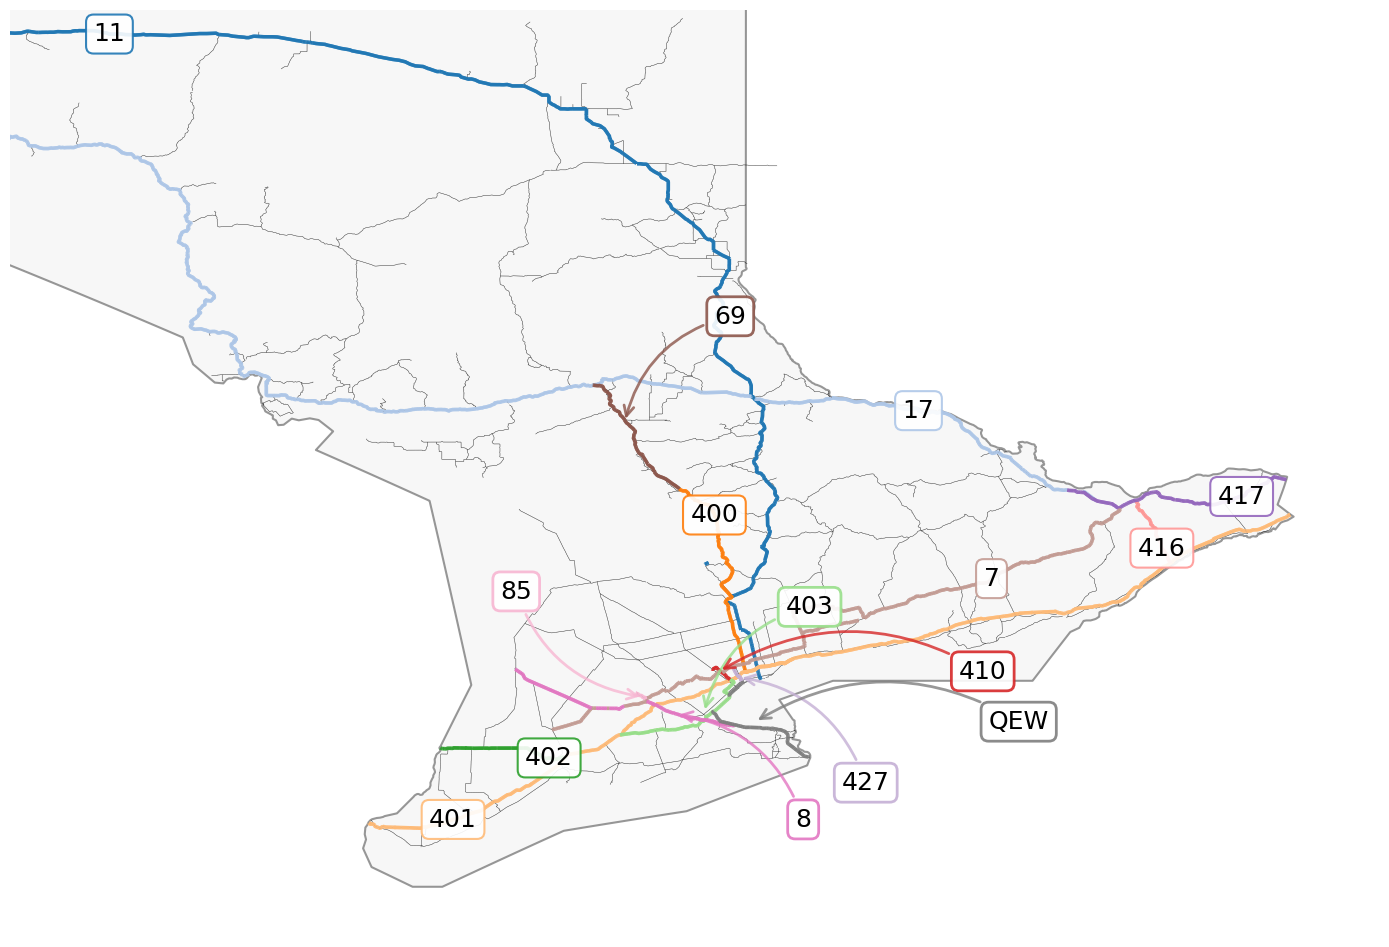

✓ Individual highway map displayed with smart labels
  - 15 unique highways visualized
  - 5245 total road segments
  - 7 highways with arrow labels
  - 8 highways with direct labels


In [123]:
# Create map with individual highway colors and smart label placement
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=1.5, alpha=0.5, zorder=0)

# Plot base network (background highways in black)
gdf_all.plot(ax=ax, color='#000000', linewidth=0.3, alpha=0.5, zorder=1)

# Get distinct colors for each highway
highways_list = sorted(gdf_targets['matched_highway'].unique())
colors_palette = get_distinct_colors(len(highways_list))
highway_color_map = {hwy: colors_palette[i] for i, hwy in enumerate(highways_list)}

# Custom label placement overrides for specific highways
label_overrides = {
    '69': {'mode': 'direct', 'description': 'Place directly over highway'},
    '8': {'mode': 'arrow', 'direction': 'lower_right', 'description': 'Place at far northwest corner'},
    '85': {'mode': 'arrow', 'direction': 'upper_left', 'description': 'Arrow to upper left'},
    '403': {'mode': 'arrow', 'direction': 'default', 'description': 'Arrow with default placement'},
    '410': {'mode': 'arrow', 'direction': 'far_right', 'description': 'Arrow to the right'},
    '427': {'mode': 'arrow', 'direction': 'lower_right', 'description': 'Arrow to lower right'},
    'QEW': {'mode': 'arrow', 'direction': 'far_right', 'description': 'Arrow to far right'},
}

# Collect segments and calculate label positions
line_segments = []
line_colors = []
highway_labels = {}
highway_bounds = {}

for hwy in highways_list:
    color = highway_color_map[hwy]
    hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
    
    all_coords = []
    all_segments = []
    longest_segment = None
    longest_length = 0
    
    for idx, row in hwy_gdf.iterrows():
        geom = row.geometry
        if geom.geom_type == 'LineString':
            coords = list(geom.coords)
            line_segments.append(coords)
            line_colors.append(color)
            all_coords.extend(coords)
            all_segments.append(coords)
            
            # Track longest segment for label placement
            segment_length = geom.length
            if segment_length > longest_length:
                longest_length = segment_length
                longest_segment = coords
    
    # Store bounds for this highway
    if all_coords:
        all_coords_array = np.array(all_coords)
        highway_bounds[hwy] = {
            'coords': all_coords_array,
            'longest_segment': longest_segment,
            'all_segments': all_segments
        }

# Calculate label positions based on overrides or smart placement
for hwy in highways_list:
    color = highway_color_map[hwy]
    bounds = highway_bounds[hwy]
    all_coords = bounds['coords']
    longest_segment = bounds['longest_segment']
    
    if hwy in label_overrides:
        override = label_overrides[hwy]
        mode = override['mode']
        
        if mode == 'direct':
            # Place label directly on highway (use longest segment midpoint)
            if longest_segment:
                segment_array = np.array(longest_segment)
                midpoint_idx = len(segment_array) // 2
                label_pos = tuple(segment_array[midpoint_idx])
            else:
                label_pos = tuple(all_coords.mean(axis=0))
            highway_labels[hwy] = {'pos': label_pos, 'mode': 'direct', 'color': color}
            
        elif mode == 'northwest_corner':
            # Find furthest west point (minimum longitude)
            label_pos = tuple(all_coords[np.argmin(all_coords[:, 0])])
            highway_labels[hwy] = {'pos': label_pos, 'mode': 'direct', 'color': color}
            
        elif mode == 'arrow':
            # Calculate center for arrow placement
            center = all_coords.mean(axis=0)
            direction = override.get('direction', 'default')
            
            # Calculate offset position based on direction
            if direction == 'upper_left':
                label_pos = (center[0] - 1.2, center[1] + 1.0)
            elif direction == 'far_northwest':
                label_pos = (center[0] - 2.2, center[1] + 1.5)
            elif direction == 'far_left':
                label_pos = (center[0] - 2.5, center[1])
            elif direction == 'far_right':
                label_pos = (center[0] + 2.5, center[1])
            elif direction == 'right':
                label_pos = (center[0] + 1.8, center[1])
            elif direction == 'lower_right':
                label_pos = (center[0] + 1.2, center[1] - 1.0)
            else:  # default
                label_pos = (center[0] + 1.0, center[1] + 1.0)
            
            highway_labels[hwy] = {
                'pos': label_pos,
                'mode': 'arrow',
                'arrow_to': tuple(center),
                'color': color
            }
    else:
        # Smart default placement using longest segment midpoint
        if longest_segment:
            segment_array = np.array(longest_segment)
            midpoint_idx = len(segment_array) // 2
            label_pos = tuple(segment_array[midpoint_idx])
        else:
            label_pos = tuple(all_coords.mean(axis=0))
        
        highway_labels[hwy] = {'pos': label_pos, 'mode': 'direct', 'color': color}

# Check for overlaps and convert to arrows if needed
overlap_threshold = 0.6
placed_positions = []

for hwy in highways_list:
    if highway_labels[hwy]['mode'] == 'direct':
        label_pos = highway_labels[hwy]['pos']
        
        # Check if this position overlaps with any already placed labels
        overlaps = False
        for placed_pos in placed_positions:
            distance = np.sqrt((label_pos[0] - placed_pos[0])**2 + (label_pos[1] - placed_pos[1])**2)
            if distance < overlap_threshold:
                overlaps = True
                break
        
        if overlaps:
            # Convert to arrow placement
            bounds = highway_bounds[hwy]
            center = bounds['coords'].mean(axis=0)
            
            # Find a good offset direction
            offset_pos = (center[0] + 1.0, center[1] + 1.0)
            highway_labels[hwy] = {
                'pos': offset_pos,
                'mode': 'arrow',
                'arrow_to': tuple(center),
                'color': highway_labels[hwy]['color']
            }
            placed_positions.append(offset_pos)
        else:
            placed_positions.append(label_pos)
    else:
        placed_positions.append(highway_labels[hwy]['pos'])

# Add colored line collection
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=2.5, alpha=0.85, zorder=3)
    ax.add_collection(lc)
    ax.autoscale()

# Add labels with arrows where appropriate
for hwy, label_info in highway_labels.items():
    color = label_info['color']
    pos = label_info['pos']
    
    if label_info['mode'] == 'arrow':
        # Add arrow pointing to highway
        arrow_to = label_info['arrow_to']
        ax.annotate(
            f'{hwy}',
            xy=arrow_to,
            xytext=pos,
            fontsize=18,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=2, alpha=0.9),
            arrowprops=dict(
                arrowstyle='->',
                connectionstyle='arc3,rad=0.3',
                color=color,
                linewidth=2,
                alpha=0.8
            ),
            zorder=5
        )
    else:
        # Direct label placement
        ax.text(pos[0], pos[1], f'{hwy}', 
                fontsize=18, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=1.5, alpha=0.9),
                zorder=5)

# Define southern Ontario zoom bounds (GTA + surrounding region)
# Longitude: -80.5 to -79.0, Latitude: 43.2 to 44.2
min_lon, max_lon = -86.5, -73.5
min_lat, max_lat = 41.2, 50.0

# Set axis limits to zoom into southern Ontario (faster rendering)
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# Remove title, axis labels, ticks, and grid
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(project_root / "plots/highway_network_map_by_highway.png", dpi=500)
plt.savefig(project_root / "plots/highway_network_map_by_highway.pdf")
plt.show()

print("✓ Individual highway map displayed with smart labels")
print(f"  - {len(highways_list)} unique highways visualized")
print(f"  - {len(line_segments)} total road segments")
print(f"  - {sum(1 for l in highway_labels.values() if l['mode'] == 'arrow')} highways with arrow labels")
print(f"  - {sum(1 for l in highway_labels.values() if l['mode'] == 'direct')} highways with direct labels")

## 6. Weighted Visualizations

Create maps with line width weighted by traffic and goods attributes:
- **AADTT16**: Annual Average Daily Truck Traffic (2016)
- **VOG_WGT**: Value of Goods Weight
- **VOG16**: Value of Goods (2016)

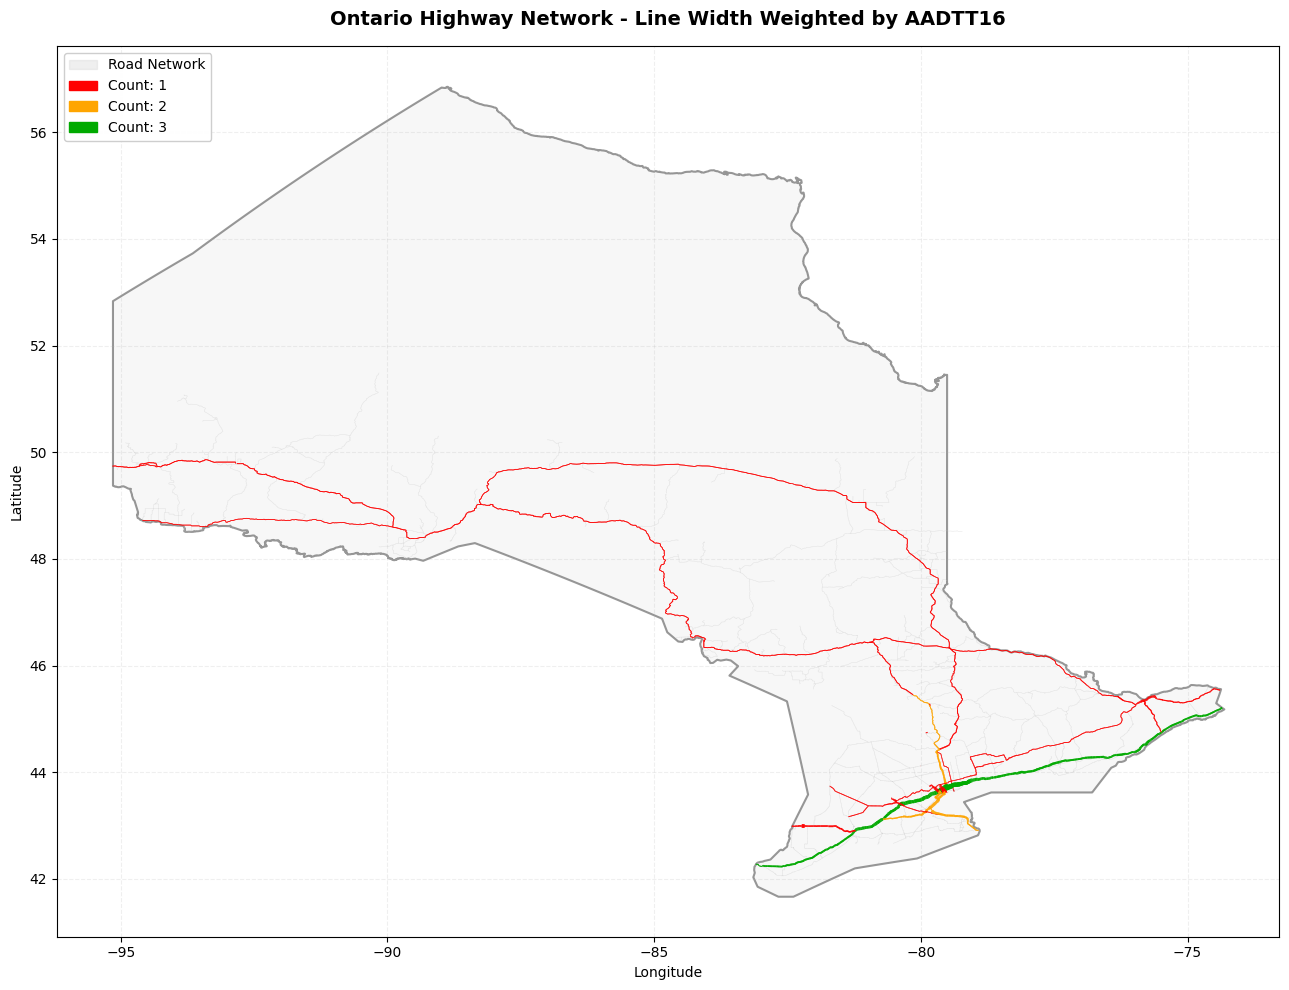

✓ Weighted map (AADTT16) displayed
  - Line width range: 0.50 to 4.50
  - AADTT16 range: 0 to 22223


In [29]:
# Create a weighted visualization example (AADTT16)
weight_by = 'AADTT16'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=1.5, alpha=0.5, zorder=0)

# Plot base network
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.3, zorder=1)

# Get min/max for weight normalization
valid_values = gdf_targets[weight_by].dropna()
if len(valid_values) > 0:
    min_val = valid_values.min()
    max_val = valid_values.max()
    if max_val == min_val:
        min_val = max_val - 1
else:
    min_val = 1
    max_val = 1

# Create colored segments with varying widths
line_segments = []
line_colors = []
line_widths = []

for hwy in sorted(gdf_targets['matched_highway'].unique()):
    if hwy in highway_info:
        count = highway_info[hwy]['count']
        color = get_highway_color(count)
        
        hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
        
        for idx, row in hwy_gdf.iterrows():
            # Calculate width based on attribute value
            if pd.notna(row[weight_by]) and max_val > min_val:
                normalized = (row[weight_by] - min_val) / (max_val - min_val)
                linewidth = 0.5 + normalized * 4  # Width from 0.5 to 4.5
            else:
                linewidth = 2.5
            
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments.append(coords)
                line_colors.append(color)
                line_widths.append(linewidth)

# Add line collection with varying widths
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=line_widths, alpha=0.85, zorder=3)
    ax.add_collection(lc)
    ax.autoscale()

# Create legend
legend_elements = [
    mpatches.Patch(color='#CCCCCC', alpha=0.3, label='Road Network'),
    mpatches.Patch(color='#FF0000', label='Count: 1'),
    mpatches.Patch(color='#FFA500', label='Count: 2'),
    mpatches.Patch(color='#00AA00', label='Count: 3')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

ax.set_title(f'Ontario Highway Network - Line Width Weighted by {weight_by}', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print(f"✓ Weighted map ({weight_by}) displayed")
print(f"  - Line width range: {min(line_widths):.2f} to {max(line_widths):.2f}")
print(f"  - {weight_by} range: {min_val:.0f} to {max_val:.0f}")

## 7. Export Maps

Use the map generation functions to export high-resolution PDF and PNG files for all visualizations.

In [30]:
# Export all map variants as high-resolution PDF and PNG files (300 DPI)
output_dir = '../plots'

print("Exporting maps...")
print()

# Map 1: Basic map with colors by count
print("1/3: Exporting basic map...")
fig, ax = create_pdf_map(gdf_all, gdf_targets, gdf_ontario, highways_df, 
                         'highway_network_map.pdf', output_dir)
plt.close(fig)

# Map 2: Weighted by AADTT16
print("2/3: Exporting AADTT16 weighted map...")
fig, ax = create_weighted_pdf_map(gdf_all, gdf_targets, gdf_ontario, highways_df, 
                                   'AADTT16', 'highway_network_map_aadtt16.pdf', output_dir)
plt.close(fig)

# Map 3: Weighted by VOG16
print("3/3: Exporting VOG16 weighted map...")
fig, ax = create_weighted_pdf_map(gdf_all, gdf_targets, gdf_ontario, highways_df, 
                                   'VOG16', 'highway_network_map_vog16.pdf', output_dir)
plt.close(fig)

print()
print("✓ All maps exported successfully!")
print(f"  Location: {output_dir}/")
print("  Format: PDF and PNG (300 DPI)")

Exporting maps...

1/3: Exporting basic map...
2/3: Exporting AADTT16 weighted map...
3/3: Exporting VOG16 weighted map...

✓ All maps exported successfully!
  Location: ../plots/
  Format: PDF and PNG (300 DPI)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f2eba73f-2262-40cf-8fa2-7979a0070886' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

# Postal Code and Forward Sortation Area Analysis

Visualize survey postal codes as Forward Sortation Areas (FSAs) on a map of Ontario with customizable label placement.

In [31]:
# Import FSA analysis module
import importlib
sys.path.insert(0, '../source')
import postal_code_analysis
importlib.reload(postal_code_analysis)

from postal_code_analysis import (
    load_fsa_shapefile,
    load_postal_codes,
    load_ontario_boundary,
    filter_fsa_by_postal_codes,
    visualize_fsas
)

# Load postal codes
postal_codes_path = os.path.join(data_dir, 'postal_codes.csv')
df_postal = load_postal_codes(postal_codes_path)

print(f"Unique FSAs: {sorted(df_postal['FSA'].unique())}")

Loaded 24 records from postal codes CSV
Columns: ['Postal Code', 'Count']
Extracted 23 unique FSAs
FSAs: ['K0A', 'K0C', 'K0H', 'K0K', 'K6J', 'K6V', 'K7A', 'K7G', 'K8A', 'K9J', 'L0J', 'L3C', 'L4M', 'L4N', 'L5T', 'L6T', 'L6Y', 'L7E', 'M8V', 'N5A', 'N5C', 'N5W', 'P3E']
Unique FSAs: ['K0A', 'K0C', 'K0H', 'K0K', 'K6J', 'K6V', 'K7A', 'K7G', 'K8A', 'K9J', 'L0J', 'L3C', 'L4M', 'L4N', 'L5T', 'L6T', 'L6Y', 'L7E', 'M8V', 'N5A', 'N5C', 'N5W', 'P3E']


In [32]:
# Load FSA shapefile and filter to target postal codes
fsa_shapefile = os.path.join(data_dir, 'lfsa000b21a_e', 'lfsa000b21a_e.shp')
ontario_boundary_path = os.path.join(data_dir, 'Ontario_Provincial_Boundary.geojson')

# Load data using imported functions
gdf_fsa_all = load_fsa_shapefile(fsa_shapefile)
gdf_boundary_fsa = load_ontario_boundary(ontario_boundary_path)
gdf_fsa_target = filter_fsa_by_postal_codes(gdf_fsa_all, df_postal, gdf_boundary_fsa)

print(f"Loaded {len(gdf_fsa_all)} Ontario FSA records")
print(f"Filtered to {len(gdf_fsa_target)} FSA features matching target postal codes")

Loaded shapefile with 1643 total FSA records
Filtered to 520 Ontario FSA records
Loaded Ontario boundary

[FSA Filter] Coordinate Systems:
  FSA shapefile CRS: EPSG:3347
  Ontario boundary CRS: EPSG:4326
  → Reprojecting FSA shapefile to EPSG:4326
Filtered to 23 FSA features matching target postal codes
Loaded 520 Ontario FSA records
Filtered to 23 FSA features matching target postal codes


In [33]:
# Save target FSAs to GeoJSON
from pathlib import Path
from postal_code_analysis import save_target_fsa_geojson

target_fsa_path = Path(data_dir) / 'target_fsas.geojson'
save_target_fsa_geojson(gdf_fsa_target, target_fsa_path)
print(f"✓ Saved target FSAs to {target_fsa_path}")

[FSA Export] Saved 23 target FSAs to ../data/target_fsas.geojson
✓ Saved target FSAs to ../data/target_fsas.geojson


In [34]:
# Configure label directions for small FSAs
# Options: 'up', 'down', 'left', 'right', 'upper left', 'upper right', 'lower left', 'lower right'
label_directions = {
    'L4N': 'left',
    'K7G': 'right',
    'K6V': 'lower right',
    'K7A': 'down',
    'K6J': 'down',
    'L6Y': 'lower left',
    'L5T': 'down',
    'L6T': 'left'
}

✓ FSA visualization saved to ../plots/fsa_visualization.png


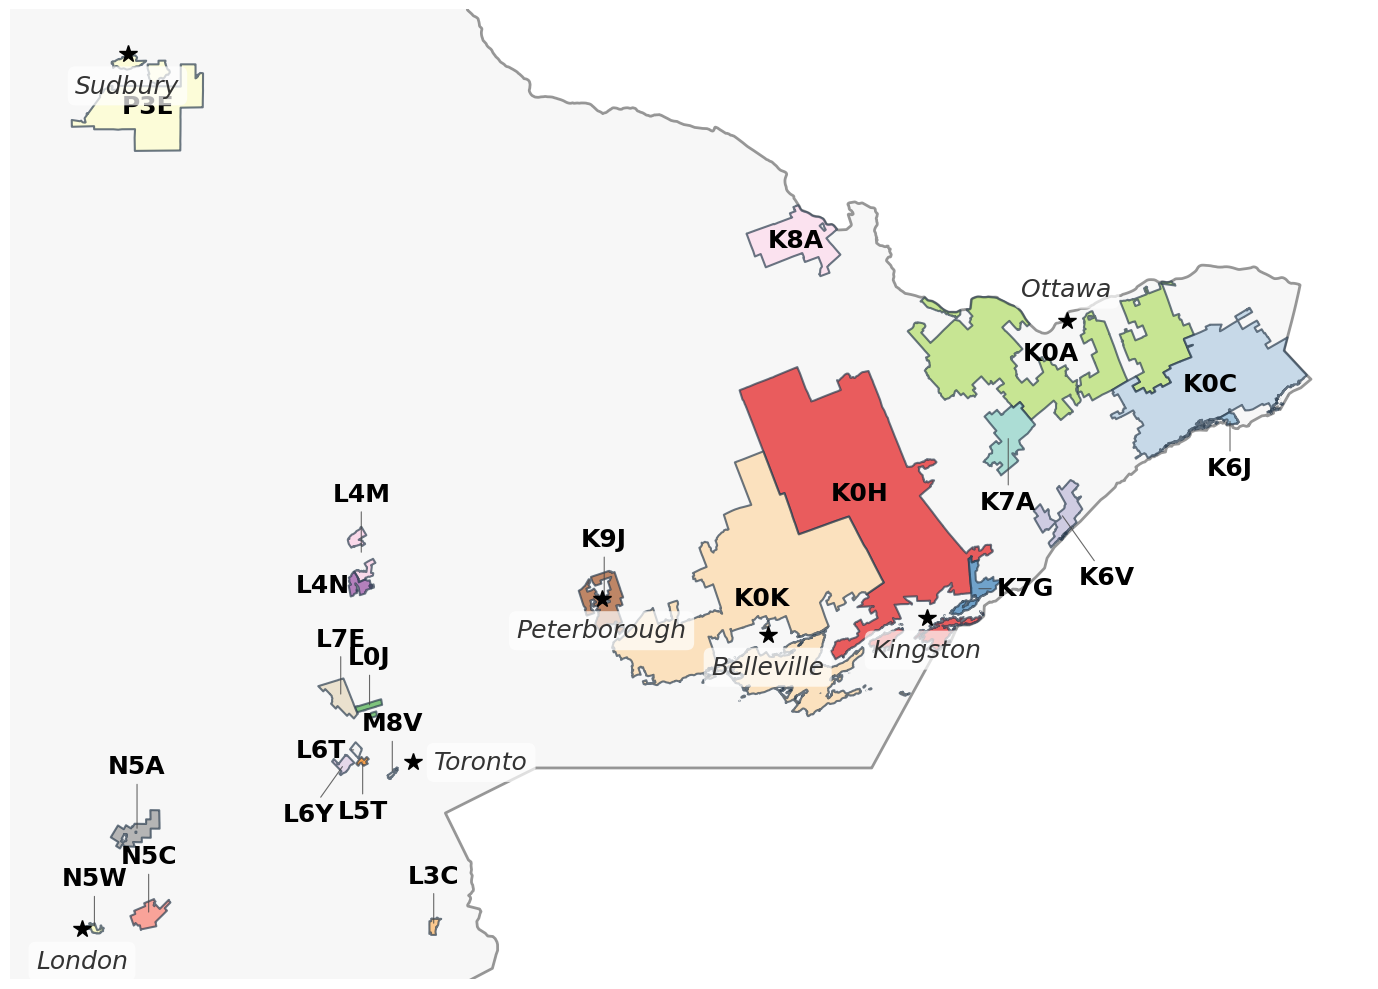

In [ ]:
# Create FSA visualization using imported function (with title and axes removed)
output_path = os.path.join(output_dir, 'fsa_visualization.png')

# Inline the visualization with styling removed
fig, ax = plt.subplots(figsize=(14, 10))

# Build a color palette with high contrast
fsa_codes = gdf_fsa_target['CFSAUID'].str[:3].unique()
n_colors = len(fsa_codes)

# Use a curated palette of visually distinct colors
distinct_colors = [
    '#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#A65628', '#F781BF', '#999999',
    '#B3DE69', '#BEBADA', '#FB8072', '#80B1D3', '#FDB462', '#8DD3C7', '#FFFFB3', '#FCCDE5',
    '#B3CDE3', '#DECBE4', '#FED9A6', '#FFFFCC', '#E5D8BD', '#FDDAEC', '#F2F2F2', '#CCCCCC',
]

# Shuffle palette and assign colors
np.random.seed(42)
shuffled_palette = distinct_colors.copy()
np.random.shuffle(shuffled_palette)
color_map = dict(zip(fsa_codes, shuffled_palette[:n_colors]))

gdf_fsa_target_colored = gdf_fsa_target.assign(_fsa_color=gdf_fsa_target['CFSAUID'].str[:3].map(color_map))

# Plot Ontario boundary
gdf_boundary_fsa.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=2, alpha=0.5, zorder=0)

# Plot target FSAs
gdf_fsa_target_colored.plot(ax=ax, color=list(gdf_fsa_target_colored['_fsa_color']), 
                            edgecolor='#2c3e50', linewidth=1.5, alpha=0.7, zorder=2)

# Add FSA labels
for idx, row in gdf_fsa_target_colored.iterrows():
    centroid = row.geometry.centroid
    fsa_code = row['CFSAUID'][:3]
    minx, miny, maxx, maxy = row.geometry.bounds
    max_span = max(maxx - minx, maxy - miny)
    small_feature = max_span < 0.4
    label_x, label_y = centroid.x, centroid.y
    
    if small_feature:
        offset = 0.12 + max(max_span * 0.5, 0.08)
        direction = label_directions.get(fsa_code, 'up')
        
        if direction == 'up':
            label_y += offset
        elif direction == 'down':
            label_y -= offset
        elif direction == 'right':
            label_x += offset
        elif direction == 'left':
            label_x -= offset
        elif direction == 'upper right':
            label_x += offset
            label_y += offset
        elif direction == 'upper left':
            label_x -= offset
            label_y += offset
        elif direction == 'lower right':
            label_x += offset
            label_y -= offset
        elif direction == 'lower left':
            label_x -= offset
            label_y -= offset
    
    ax.annotate(
        fsa_code,
        xy=(centroid.x, centroid.y),
        xytext=(label_x, label_y),
        fontsize=18,
        ha='center',
        va='center',
        fontweight='bold',
        color='black',
        zorder=3,
        arrowprops=dict(arrowstyle='-', color='#444444', lw=0.8, alpha=0.8) if small_feature else None
    )

# Zoom to extent of target FSAs with padding
minx, miny, maxx, maxy = gdf_fsa_target_colored.total_bounds
x_pad = (maxx - minx) * 0.05
y_pad = (maxy - miny) * 0.05
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

# Add major cities for context
major_cities = {
    'Toronto': (-79.3832, 43.6532),
    'Ottawa': (-75.6972, 45.4215),
    'Kingston': (-76.4860, 44.2312),
    'Belleville': (-77.3832, 44.1628),
    'Peterborough': (-78.3197, 44.3091),
    'London': (-81.2497, 42.9849),
    'Windsor': (-83.0368, 42.3149),
    'Sudbury': (-80.9930, 46.4917),
}

for city, (lon, lat) in major_cities.items():
    if minx - x_pad <= lon <= maxx + x_pad and miny - y_pad <= lat <= maxy + y_pad:
        ax.plot(lon, lat, marker='*', color='black', markersize=13, zorder=4)
        # Place Ottawa label 0.12 above, Toronto to the right, others 0.12 below
        if city == 'Ottawa' or city == 'Sudbury':
            label_x, label_y = lon, lat + 0.08
            ha, va = 'center', 'bottom'
        elif city == 'Toronto':
            label_x, label_y = lon + 0.12, lat
            ha, va = 'left', 'center'
        else:
            label_x, label_y = lon, lat - 0.08
            ha, va = 'center', 'top'
        ax.text(label_x, label_y, city, fontsize=18, ha=ha,
                va=va, style='italic', color='#333333', zorder=4,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='none', alpha=0.7))

# Remove title, axis labels, ticks, and grid
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ FSA visualization saved to {output_path}")
plt.show()

## Highway Network Overlaid on Target FSAs

Combine the FSA visualization with highway network plots, showing:
1. Basic highway network (by survey count) on FSA background
2. AADTT16 weighted highway network on FSA background

In [36]:
# Load refueling stops data
refueling_stops_path = os.path.join(data_dir, 'refueling_stops.csv')

try:
    df_refueling = pd.read_csv(refueling_stops_path)
    
    # Check if the file has data
    if len(df_refueling) > 0:
        # Check for required columns
        required_cols = ['City', 'Count', 'Latitude', 'Longitude']
        if all(col in df_refueling.columns for col in required_cols):
            # Filter out rows with missing coordinates
            df_refueling = df_refueling.dropna(subset=['Longitude', 'Latitude'])
            
            if len(df_refueling) > 0:
                print(f"✓ Loaded {len(df_refueling)} refueling stops with coordinates")
                print(f"Cities: {sorted(df_refueling['City'].unique())}")
            else:
                print("⚠ No refueling stops have valid coordinates")
                df_refueling = None
        else:
            print(f"⚠ Refueling stops file missing required columns: {required_cols}")
            df_refueling = None
    else:
        print("⚠ Refueling stops file is empty")
        df_refueling = None
        
except FileNotFoundError:
    print(f"⚠ File not found: {refueling_stops_path}")
    df_refueling = None
except Exception as e:
    print(f"⚠ Error loading refueling stops: {e}")
    df_refueling = None

# Configure city label positions (above or below icon)
# Options: 'above', 'below' (default is 'below')
city_label_positions = {
    'Bolton': 'above'
}

✓ Loaded 4 refueling stops with coordinates
Cities: ['Bolton', 'Brampton', 'Kingston', 'Sudbury']


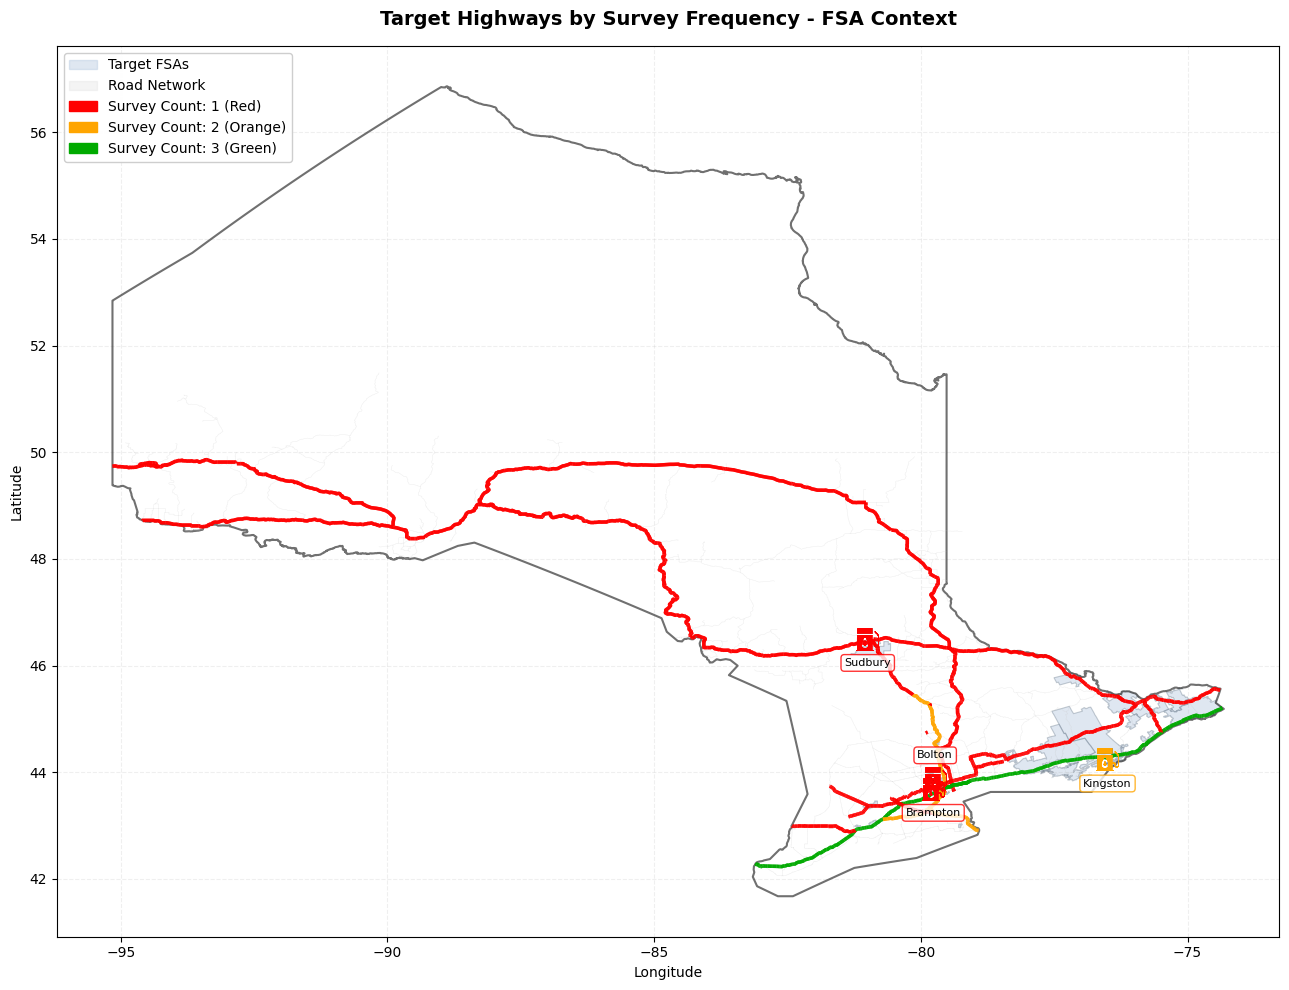

✓ Highway network with FSA overlay displayed
  - 4 refueling stops marked with colored SVG icons
  - 5245 highway segments colored by survey count
  - 23 FSAs shown in muted blue


In [37]:
# Create map with highways by survey count overlaid on FSAs (muted blue)
fig, ax = plt.subplots(figsize=(14, 10))

# Set background color
ax.set_facecolor('white')

# Plot FSAs in muted blue
gdf_fsa_target.plot(ax=ax, color='#B0C4DE', edgecolor='#708090', linewidth=0.8, alpha=0.4, zorder=1)

# Add Ontario boundary
gdf_boundary_fsa.plot(ax=ax, color='none', edgecolor='#333333', linewidth=1.5, alpha=0.7, zorder=2)

# Plot base network (all roads in light gray)
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.2, zorder=3)

# Collect and plot colored highway segments
line_segments = []
line_colors = []

for hwy in sorted(gdf_targets['matched_highway'].unique()):
    if hwy in highway_info:
        count = highway_info[hwy]['count']
        color = get_highway_color(count)
        
        hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
        
        for idx, row in hwy_gdf.iterrows():
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments.append(coords)
                line_colors.append(color)

# Add colored line collection
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=2.5, alpha=0.85, zorder=4)
    ax.add_collection(lc)
    ax.autoscale()

# Add refueling stops with colored SVG icons
if df_refueling is not None and len(df_refueling) > 0:
    svg_path = os.path.join(data_dir, 'noun-gas-station-8102461.svg')
    
    if os.path.exists(svg_path):
        from matplotlib.offsetbox import OffsetImage, AnnotationBbox
        from io import BytesIO
        from PIL import Image
        import cairosvg
        
        # Plot refueling stops
        for idx, row in df_refueling.iterrows():
            count = row['Count']
            color = get_highway_color(count)
            # Convert hex color to RGB
            color_rgb = tuple(int(color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
            
            try:
                # Convert SVG to PNG in memory at larger size
                png_bytes = BytesIO()
                cairosvg.svg2png(url=svg_path, write_to=png_bytes, output_width=96, output_height=96)
                png_bytes.seek(0)
                svg_image = Image.open(png_bytes).convert('RGBA')
                
                # Colorize the icon by replacing RGB values while preserving alpha
                data = np.array(svg_image)
                colored_data = data.copy()
                mask = data[:, :, 3] > 0
                colored_data[mask, 0] = color_rgb[0]
                colored_data[mask, 1] = color_rgb[1]
                colored_data[mask, 2] = color_rgb[2]
                svg_image = Image.fromarray(colored_data, 'RGBA')
                
                # Display SVG image (bigger with zoom=0.2)
                imagebox = OffsetImage(svg_image, zoom=0.2, alpha=1.0)
                ab = AnnotationBbox(imagebox, (row['Longitude'], row['Latitude']),
                                  frameon=False, pad=0)
                ab.set_zorder(8)
                ax.add_artist(ab)
            except Exception as e:
                # Fallback to colored marker
                ax.scatter(row['Longitude'], row['Latitude'], 
                          marker='o', s=400, c=color, edgecolors='black', 
                          linewidths=2.5, alpha=0.85, zorder=8)
    
    # Add city labels for all refueling stops
    for idx, row in df_refueling.iterrows():
        count = row['Count']
        color = get_highway_color(count)
        city = row['City']
        
        # Check if label should be above or below icon
        label_position = city_label_positions.get(city, 'below')
        if label_position == 'above':
            label_y = row['Latitude'] + 0.35
            va_align = 'bottom'
        else:  # below
            label_y = row['Latitude'] - 0.35
            va_align = 'top'
        
        ax.text(row['Longitude'], label_y, city,
               fontsize=8, ha='center', va=va_align,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor=color, linewidth=1, alpha=0.8),
               zorder=7)

# Create legend
legend_elements = [
    mpatches.Patch(color='#B0C4DE', alpha=0.4, label='Target FSAs'),
    mpatches.Patch(color='#CCCCCC', alpha=0.2, label='Road Network'),
    mpatches.Patch(color='#FF0000', label='Survey Count: 1 (Red)'),
    mpatches.Patch(color='#FFA500', label='Survey Count: 2 (Orange)'),
    mpatches.Patch(color='#00AA00', label='Survey Count: 3 (Green)')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

ax.set_title('Target Highways by Survey Frequency - FSA Context', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print(f"✓ Highway network with FSA overlay displayed")
if df_refueling is not None and len(df_refueling) > 0:
    print(f"  - {len(df_refueling)} refueling stops marked with colored SVG icons")
print(f"  - {len(line_segments)} highway segments colored by survey count")
print(f"  - {len(gdf_fsa_target)} FSAs shown in muted blue")

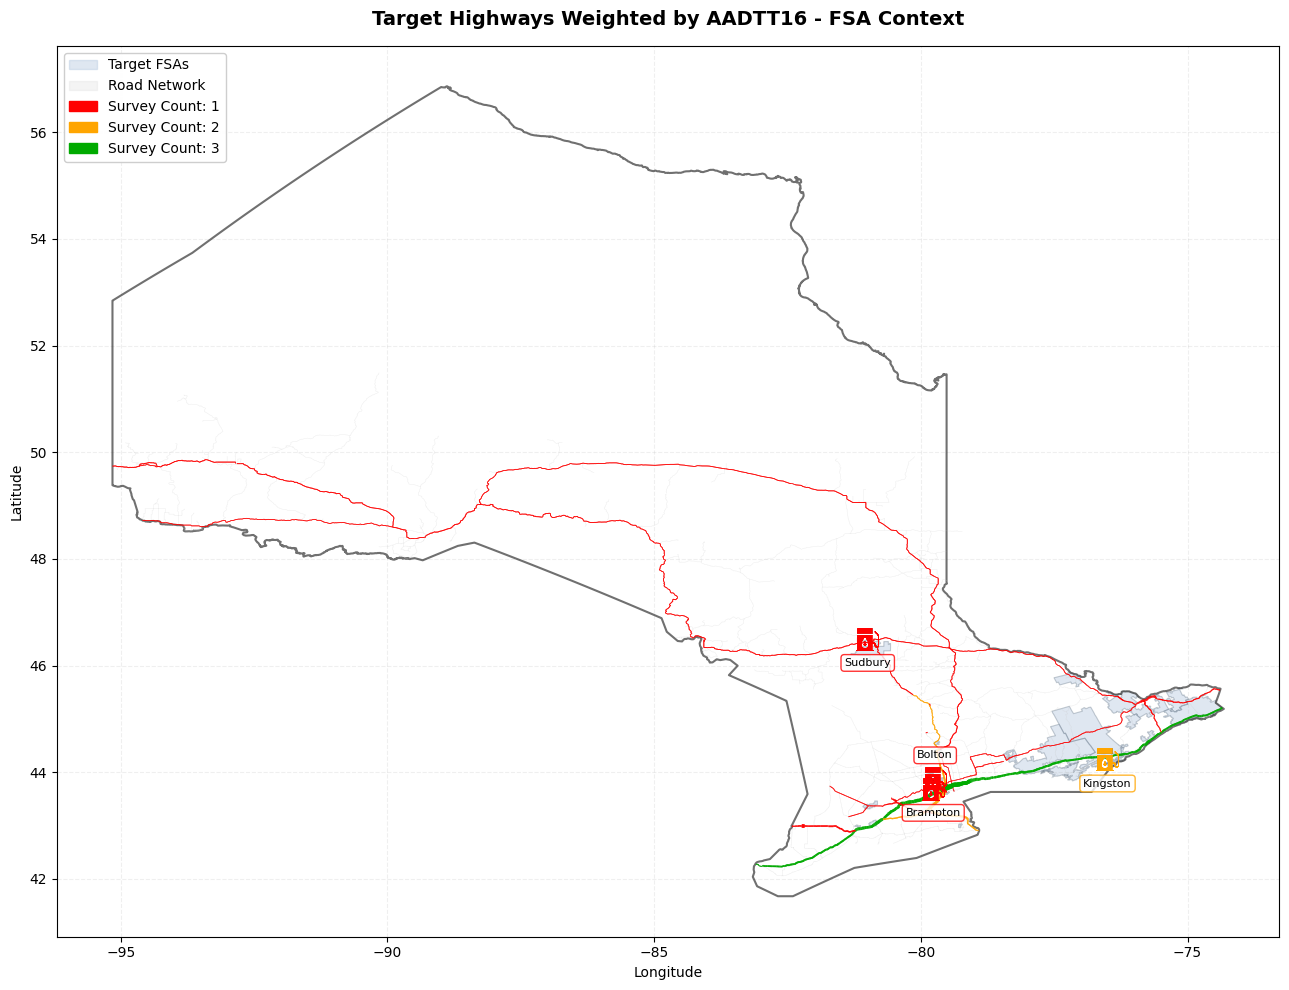

✓ Weighted highway map (AADTT16) with FSA overlay displayed
  - 4 refueling stops marked with colored SVG icons
  - Line width range: 0.50 to 4.50
  - AADTT16 range: 0 to 22223


In [87]:
# Create map with AADTT16-weighted highways overlaid on FSAs (muted blue)
weight_by = 'AADTT16'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot FSAs in muted blue
gdf_fsa_target.plot(ax=ax, color='#B0C4DE', edgecolor='#708090', linewidth=0.8, alpha=0.4, zorder=1)

# Add Ontario boundary
gdf_boundary_fsa.plot(ax=ax, color='none', edgecolor='#333333', linewidth=1.5, alpha=0.7, zorder=2)

# Plot base network
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.2, zorder=3)

# Get min/max for weight normalization
valid_values = gdf_targets[weight_by].dropna()
if len(valid_values) > 0:
    min_val = valid_values.min()
    max_val = valid_values.max()
    if max_val == min_val:
        min_val = max_val - 1
else:
    min_val = 1
    max_val = 1

# Create colored segments with varying widths
line_segments = []
line_colors = []
line_widths = []

for hwy in sorted(gdf_targets['matched_highway'].unique()):
    if hwy in highway_info:
        count = highway_info[hwy]['count']
        color = get_highway_color(count)
        
        hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
        
        for idx, row in hwy_gdf.iterrows():
            # Calculate width based on attribute value
            if pd.notna(row[weight_by]) and max_val > min_val:
                normalized = (row[weight_by] - min_val) / (max_val - min_val)
                linewidth = 0.5 + normalized * 4  # Width from 0.5 to 4.5
            else:
                linewidth = 2.5
            
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments.append(coords)
                line_colors.append(color)
                line_widths.append(linewidth)

# Add line collection with varying widths
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=line_widths, alpha=0.85, zorder=5)
    ax.add_collection(lc)
    ax.autoscale()

# Add refueling stops with colored SVG icons
if df_refueling is not None and len(df_refueling) > 0:
    svg_path = os.path.join(data_dir, 'noun-gas-station-8102461.svg')
    
    if os.path.exists(svg_path):
        from matplotlib.offsetbox import OffsetImage, AnnotationBbox
        from io import BytesIO
        from PIL import Image
        import cairosvg
        
        # Plot refueling stops
        for idx, row in df_refueling.iterrows():
            count = row['Count']
            color = get_highway_color(count)
            # Convert hex color to RGB
            color_rgb = tuple(int(color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
            
            try:
                # Convert SVG to PNG in memory at larger size
                png_bytes = BytesIO()
                cairosvg.svg2png(url=svg_path, write_to=png_bytes, output_width=96, output_height=96)
                png_bytes.seek(0)
                svg_image = Image.open(png_bytes).convert('RGBA')
                
                # Colorize the icon by replacing RGB values while preserving alpha
                data = np.array(svg_image)
                colored_data = data.copy()
                mask = data[:, :, 3] > 0
                colored_data[mask, 0] = color_rgb[0]
                colored_data[mask, 1] = color_rgb[1]
                colored_data[mask, 2] = color_rgb[2]
                svg_image = Image.fromarray(colored_data, 'RGBA')
                
                # Display SVG image (bigger with zoom=0.2)
                imagebox = OffsetImage(svg_image, zoom=0.2, alpha=1.0)
                ab = AnnotationBbox(imagebox, (row['Longitude'], row['Latitude']),
                                  frameon=False, pad=0)
                ab.set_zorder(8)
                ax.add_artist(ab)
            except Exception as e:
                # Fallback to colored marker
                ax.scatter(row['Longitude'], row['Latitude'], 
                          marker='o', s=400, c=color, edgecolors='black', 
                          linewidths=2.5, alpha=0.85, zorder=8)
    
    # Add city labels for all refueling stops
    for idx, row in df_refueling.iterrows():
        count = row['Count']
        color = get_highway_color(count)
        city = row['City']
        
        # Check if label should be above or below icon
        label_position = city_label_positions.get(city, 'below')
        if label_position == 'above':
            label_y = row['Latitude'] + 0.35
            va_align = 'bottom'
        else:  # below
            label_y = row['Latitude'] - 0.35
            va_align = 'top'
        
        ax.text(row['Longitude'], label_y, city,
               fontsize=8, ha='center', va=va_align,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor=color, linewidth=1, alpha=0.8),
               zorder=7)

# Create legend
legend_elements = [
    mpatches.Patch(color='#B0C4DE', alpha=0.4, label='Target FSAs'),
    mpatches.Patch(color='#CCCCCC', alpha=0.2, label='Road Network'),
    mpatches.Patch(color='#FF0000', label='Survey Count: 1'),
    mpatches.Patch(color='#FFA500', label='Survey Count: 2'),
    mpatches.Patch(color='#00AA00', label='Survey Count: 3')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

ax.set_title(f'Target Highways Weighted by {weight_by} - FSA Context', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print(f"✓ Weighted highway map ({weight_by}) with FSA overlay displayed")
if df_refueling is not None and len(df_refueling) > 0:
    print(f"  - {len(df_refueling)} refueling stops marked with colored SVG icons")
print(f"  - Line width range: {min(line_widths):.2f} to {max(line_widths):.2f}")
print(f"  - {weight_by} range: {min_val:.0f} to {max_val:.0f}")

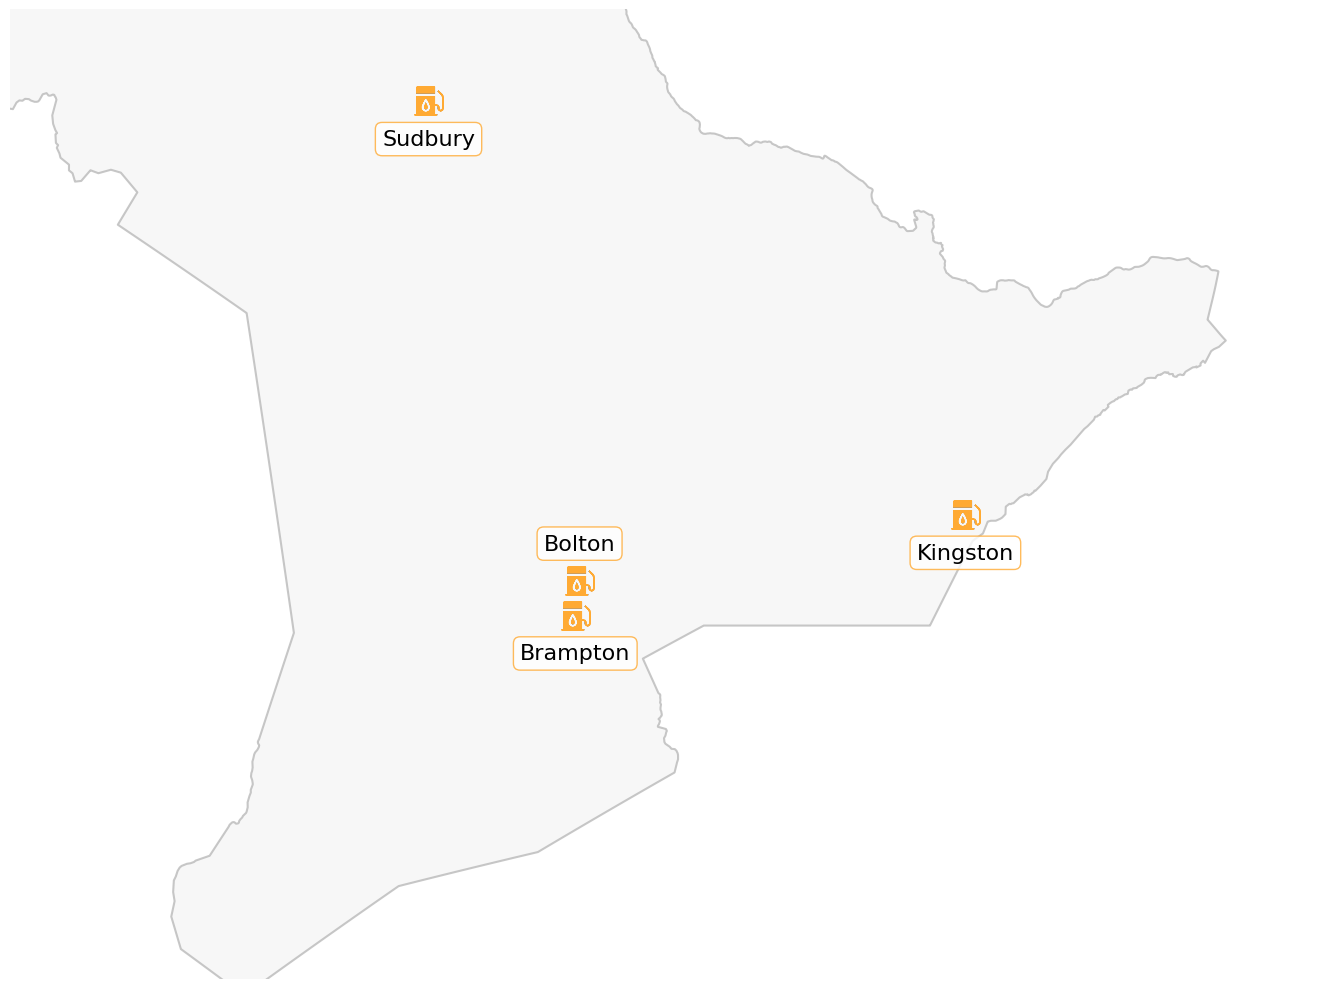

  - 4 refueling stops marked with colored SVG icons
  - Line width range: 0.50 to 4.50
  - AADTT16 range: 0 to 22223


In [106]:
# Create map with AADTT16-weighted highways overlaid on FSAs (muted blue)
weight_by = 'AADTT16'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#b0b0b0', linewidth=1.5, alpha=0.7, zorder=0)

# Define southern Ontario zoom bounds (GTA + surrounding region)
# Longitude: -80.5 to -79.0, Latitude: 43.2 to 44.2
min_lon, max_lon = -84.5, -73.5
min_lat, max_lat = 41.7, 47.0

# Add refueling stops with colored SVG icons
if df_refueling is not None and len(df_refueling) > 0:
    svg_path = os.path.join(data_dir, 'noun-gas-station-8102461.svg')
    
    if os.path.exists(svg_path):
        from matplotlib.offsetbox import OffsetImage, AnnotationBbox
        from io import BytesIO
        from PIL import Image
        import cairosvg
        
        # Plot refueling stops
        for idx, row in df_refueling.iterrows():
            count = row['Count']
            # Convert hex color to RGB
            color = "#ffaa33"
            color_rgb = tuple(int(color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
            
            try:
                # Convert SVG to PNG in memory at larger size
                png_bytes = BytesIO()
                cairosvg.svg2png(url=svg_path, write_to=png_bytes, output_width=96, output_height=96)
                png_bytes.seek(0)
                svg_image = Image.open(png_bytes).convert('RGBA')
                
                # Colorize the icon by replacing RGB values while preserving alpha
                data = np.array(svg_image)
                colored_data = data.copy()
                mask = data[:, :, 3] > 0
                colored_data[mask, 0] = color_rgb[0]
                colored_data[mask, 1] = color_rgb[1]
                colored_data[mask, 2] = color_rgb[2]
                svg_image = Image.fromarray(colored_data, 'RGBA')
                
                # Display SVG image (bigger with zoom=0.2)
                imagebox = OffsetImage(svg_image, zoom=0.25, alpha=1.0)
                ab = AnnotationBbox(imagebox, (row['Longitude'], row['Latitude']),
                                  frameon=False, pad=0)
                ab.set_zorder(8)
                ax.add_artist(ab)
            except Exception as e:
                # Fallback to colored marker
                ax.scatter(row['Longitude'], row['Latitude'], 
                          marker='o', s=800, c=color, edgecolors='black', 
                          linewidths=2.5, alpha=0.85, zorder=8)
    
    # Add city labels for all refueling stops
    for idx, row in df_refueling.iterrows():
        count = row['Count']
        color = "#ffaa33"
        city = row['City']
        
        # Check if label should be above or below icon
        label_position = city_label_positions.get(city, 'below')
        if label_position == 'above':
            label_y = row['Latitude'] + 0.15
            va_align = 'bottom'
        else:  # below
            label_y = row['Latitude'] - 0.15
            va_align = 'top'
        
        ax.text(row['Longitude'], label_y, city,
               fontsize=16, ha='center', va=va_align,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor=color, linewidth=1, alpha=0.8),
               zorder=7)

# Set axis limits to zoom into southern Ontario (faster rendering)
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "refueling_stops.png"), dpi=300, bbox_inches='tight')
plt.show()

if df_refueling is not None and len(df_refueling) > 0:
    print(f"  - {len(df_refueling)} refueling stops marked with colored SVG icons")
print(f"  - Line width range: {min(line_widths):.2f} to {max(line_widths):.2f}")
print(f"  - {weight_by} range: {min_val:.0f} to {max_val:.0f}")

In [42]:
# First, generate the GeoJSON files if they don't exist
import importlib
sys.path.insert(0, '../source')
import public_charging_analysis
importlib.reload(public_charging_analysis)

print("Generating public charging GeoJSON files...")
gdf_highways_gta, gdf_cities_points, gdf_cities_boundaries, gdf_fsas = public_charging_analysis.run_all()
print(f"✓ Generated: {len(gdf_highways_gta)} GTA highway segments")
print(f"✓ Generated: {len(gdf_cities_points)} charging cities (points)")
print(f"✓ Generated: {len(gdf_cities_boundaries)} charging cities (boundaries)")
print(f"✓ Generated: {len(gdf_fsas)} FSA boundaries")

Generating public charging GeoJSON files...

[GTA Highway Extraction] CRS Alignment:
  Roads CRS: EPSG:4326
  GTA Boundary CRS: EPSG:4326
  ✓ CRS already aligned

[Cities to GeoJSON] Created 6 city points with CRS: EPSG:4326

[Cities to GeoJSON] Loaded 686 municipalities from boundary file
  Boundary CRS: EPSG:4326
  Filtered to 7 matching city boundaries
Loaded shapefile with 1643 total FSA records
Filtered to 520 Ontario FSA records

[FSAs to GeoJSON] FSA Shapefile CRS: EPSG:3347
  Filtered to 2 FSAs with CRS: EPSG:3347

[Refueling Stops to GeoJSON] Created 4 stop points with CRS: EPSG:4326
✓ Generated: 3064 GTA highway segments
✓ Generated: 6 charging cities (points)
✓ Generated: 7 charging cities (boundaries)
✓ Generated: 2 FSA boundaries


## Public Charging Infrastructure Overlay

Visualize public charging locations, FSAs, and GTA numbered highways in bright colors.

Standalone Visualization - ZOOMED] CRS Alignment:
  Ontario boundary CRS: EPSG:4326
  GTA boundary CRS: EPSG:4326
  GTA highways CRS: EPSG:4326
  Cities Points CRS: EPSG:4326
  Cities Boundaries CRS: EPSG:4326
  FSAs CRS: EPSG:4326
  → Aligned all layers to EPSG:4326


Standalone Visualization - ZOOMED] CRS Alignment:
  Ontario boundary CRS: EPSG:4326
  GTA boundary CRS: EPSG:4326
  GTA highways CRS: EPSG:4326
  Cities Points CRS: EPSG:4326
  Cities Boundaries CRS: EPSG:4326
  FSAs CRS: EPSG:4326
  → Aligned all layers to EPSG:4326


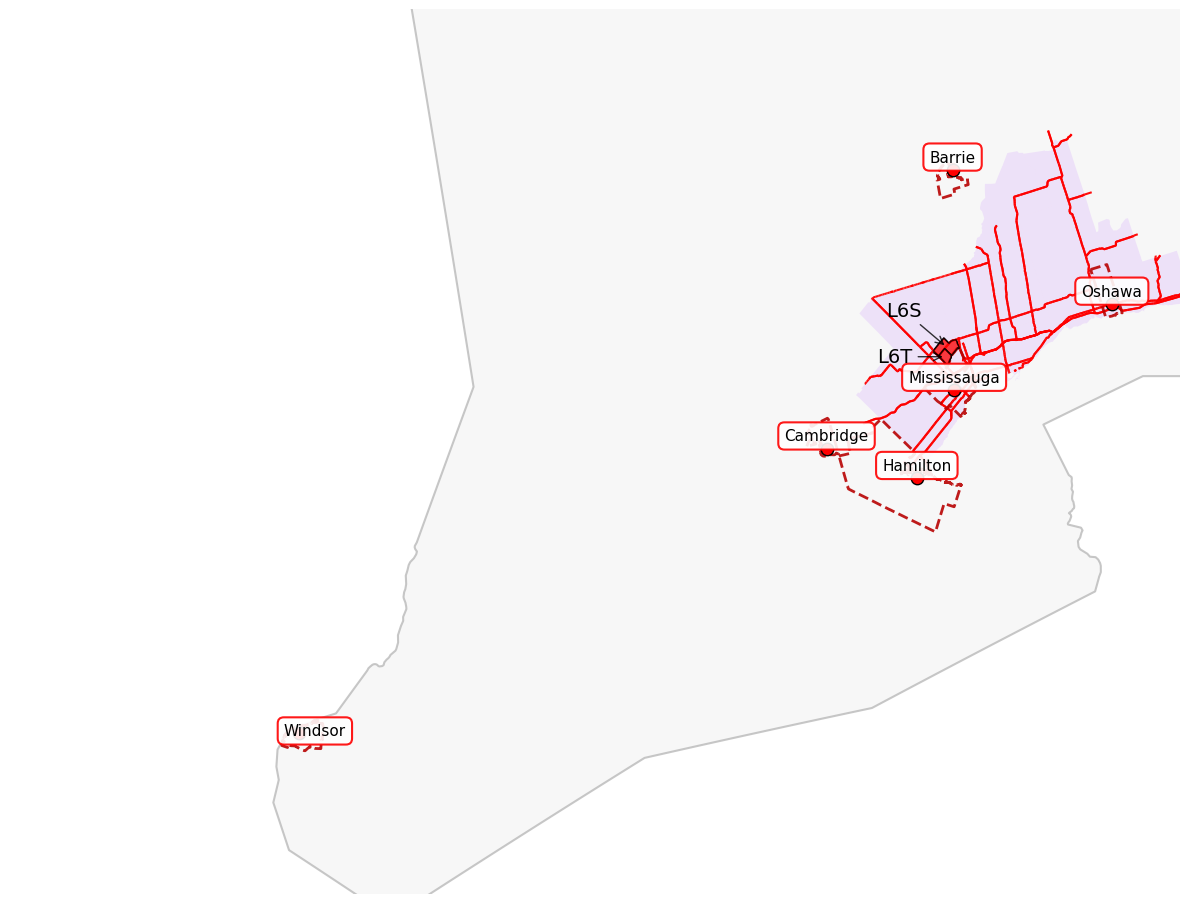

✓ Public charging standalone visualization displayed (zoomed view)


In [84]:
# Standalone visualization: Public charging overlays only (ZOOMED to Southern Ontario)
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('white')

# Load GTA boundary and Ontario boundary
gdf_gta_boundary = gpd.read_file(os.path.join(data_dir, 'GTA_Boundary.geojson'))
gdf_ontario_boundary = gpd.read_file(os.path.join(data_dir, 'Ontario_Provincial_Boundary.geojson'))

# Align CRS - ensure all layers use same CRS
print("Standalone Visualization - ZOOMED] CRS Alignment:")
print(f"  Ontario boundary CRS: {gdf_ontario_boundary.crs}")
print(f"  GTA boundary CRS: {gdf_gta_boundary.crs}")
print(f"  GTA highways CRS: {gdf_highways_gta.crs}")
print(f"  Cities Points CRS: {gdf_cities_points.crs}")
print(f"  Cities Boundaries CRS: {gdf_cities_boundaries.crs}")
print(f"  FSAs CRS: {gdf_fsas.crs}")

# Set reference CRS (prefer EPSG:4326 for consistency)
target_crs = "EPSG:4326"

if gdf_gta_boundary.crs != target_crs:
    gdf_gta_boundary = gdf_gta_boundary.to_crs(target_crs)
if gdf_ontario_boundary.crs != target_crs:
    gdf_ontario_boundary = gdf_ontario_boundary.to_crs(target_crs)
if gdf_highways_gta.crs != target_crs:
    gdf_highways_gta = gdf_highways_gta.to_crs(target_crs)
if gdf_cities_points.crs != target_crs:
    gdf_cities_points = gdf_cities_points.to_crs(target_crs)
if gdf_cities_boundaries.crs != target_crs:
    gdf_cities_boundaries = gdf_cities_boundaries.to_crs(target_crs)
if gdf_fsas.crs != target_crs:
    gdf_fsas = gdf_fsas.to_crs(target_crs)

print(f"  → Aligned all layers to {target_crs}")

# Define southern Ontario zoom bounds (GTA + surrounding region)
# Longitude: -80.5 to -79.0, Latitude: 43.2 to 44.2
min_lon, max_lon = -84.5, -78.5
min_lat, max_lat = 41.7, 45.0

# Plot Ontario boundary as a muted background (zorder 0)
gdf_ontario_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#b0b0b0', linewidth=1.5, alpha=0.7, zorder=0)

# Plot FSAs in bright yellow (zorder 2)
if not gdf_fsas.empty:
    gdf_fsas.plot(ax=ax, color='#ff0000', edgecolor='black', linewidth=1, alpha=0.75, zorder=5)
    # Overlay thin black boundaries for FSAs
    gdf_fsas.boundary.plot(ax=ax, color='black', linewidth=1.2, zorder=2.1)

# Plot highways in bright red (zorder 3)
if not gdf_highways_gta.empty:
    gdf_highways_gta.plot(ax=ax, color='#ff0000', linewidth=1.5, alpha=0.95, zorder=3)

# Plot GTA boundary outer edge in bright teal (zorder 2.5)
gdf_gta_boundary.plot(ax=ax, color='#ba66ff', edgecolor='none', linewidth=0, alpha=0.15, zorder=1.5)

# Plot city boundaries as red dashed lines (zorder 4)
if not gdf_cities_boundaries.empty:
    gdf_cities_boundaries.plot(ax=ax, facecolor='none', edgecolor='#b80303', linestyle='--', linewidth=2, alpha=0.9, zorder=4)

# Plot cities as red markers (zorder 5)
if not gdf_cities_points.empty:
    gdf_cities_points.plot(ax=ax, color='#ff0000', edgecolor='black', markersize=80, marker='o', zorder=5)
    
    # Add city labels (zorder 6)
    for idx, row in gdf_cities_points.iterrows():
        dx = 0.08 if row['City'] == 'Windsor' else 0.0
        dy = -0.02 if row['City'] == 'Windsor' else 0.02
        ax.text(row.geometry.x + dx, row.geometry.y + dy, row['City'],
               fontsize=11, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                        edgecolor='red', linewidth=1.5, alpha=0.9),
               zorder=6)

# Add FSA labels for L6S (upper left) and L6T (further left), black, larger, with arrows, no box
for idx, row in gdf_fsas.iterrows():
    if row.get('CFSAUID') == 'L6S':
        centroid = row.geometry.centroid
        bounds = row.geometry.bounds
        # Displace label to upper left of the FSA boundary
        label_x = bounds[0] - 0.45 * (bounds[2] - bounds[0])
        label_y = bounds[3] + 1 * (bounds[3] - bounds[1])
        ax.annotate(row['CFSAUID'], xy=(centroid.x, centroid.y), xytext=(label_x, label_y),
                    fontsize=14, ha='right', va='bottom', fontweight='normal', color='black',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.0, alpha=0.8),
                    zorder=7)
    elif row.get('CFSAUID') == 'L6T':
        centroid = row.geometry.centroid
        bounds = row.geometry.bounds
        # Displace label even further to the left of the FSA boundary
        label_x = bounds[0] - 2 * (bounds[2] - bounds[0])
        label_y = centroid.y
        ax.annotate(row['CFSAUID'], xy=(centroid.x, centroid.y), xytext=(label_x, label_y),
                    fontsize=14, ha='right', va='center', fontweight='normal', color='black',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.0, alpha=0.8),
                    zorder=7)

# Set axis limits to zoom into southern Ontario (faster rendering)
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# Remove axes completely
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'public_charging_standalone.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Public charging standalone visualization displayed (zoomed view)")

Overlay Visualization - ZOOMED] CRS Alignment:
  Reloading gdf_all from GeoJSON to ensure CRS is set...
  gdf_all CRS: EPSG:4326
  Target FSAs CRS: EPSG:4326
  Boundary FSAs CRS: EPSG:4326
  Target highways CRS: None


NameError: name 'gdf_highways_gta' is not defined

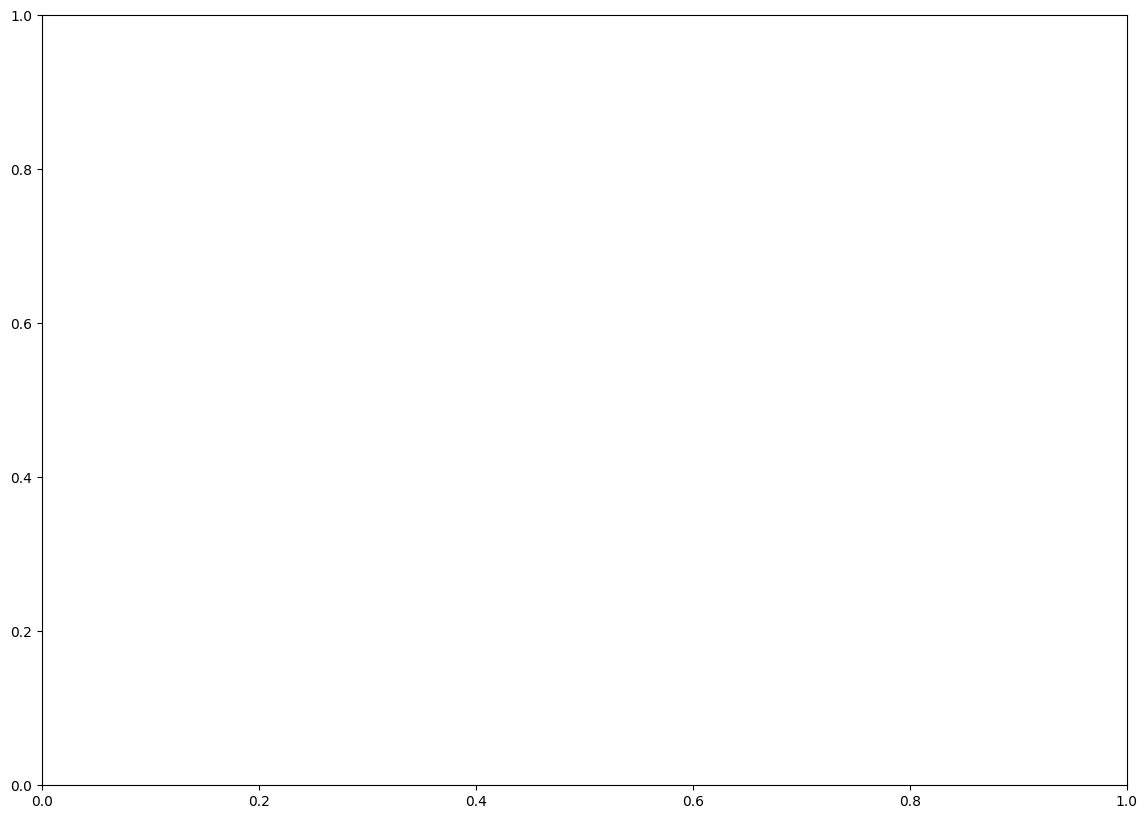

In [ ]:
# Overlay visualization: Public charging on muted background layers (ZOOMED to Southern Ontario)
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Reload gdf_all from GeoJSON to ensure it has proper CRS
print("Overlay Visualization - ZOOMED] CRS Alignment:")
print(f"  Reloading gdf_all from GeoJSON to ensure CRS is set...")
gdf_all_fresh = gpd.read_file(os.path.join(data_dir, 'Value_of_Goods_2016_-3795296180828259022.geojson'))
print(f"  gdf_all CRS: {gdf_all_fresh.crs}")

print(f"  Target FSAs CRS: {gdf_fsa_target.crs}")
print(f"  Boundary FSAs CRS: {gdf_boundary_fsa.crs}")
print(f"  Target highways CRS: {gdf_targets.crs}")
print(f"  GTA highways CRS: {gdf_highways_gta.crs}")
print(f"  Cities Points CRS: {gdf_cities_points.crs}")
print(f"  Cities Boundaries CRS: {gdf_cities_boundaries.crs}")

# Set reference CRS
target_crs = "EPSG:4326"

# Handle gdf_fsa_target
if gdf_fsa_target.crs is None:
    print(f"  ⚠ gdf_fsa_target has no CRS, assuming {target_crs}")
    gdf_fsa_target = gdf_fsa_target.set_crs(target_crs)
elif gdf_fsa_target.crs != target_crs:
    gdf_fsa_target = gdf_fsa_target.to_crs(target_crs)

# Handle gdf_boundary_fsa
if gdf_boundary_fsa.crs is None:
    print(f"  ⚠ gdf_boundary_fsa has no CRS, assuming {target_crs}")
    gdf_boundary_fsa = gdf_boundary_fsa.set_crs(target_crs)
elif gdf_boundary_fsa.crs != target_crs:
    gdf_boundary_fsa = gdf_boundary_fsa.to_crs(target_crs)

# Handle gdf_all
if gdf_all_fresh.crs is None:
    print(f"  ⚠ gdf_all has no CRS, assuming {target_crs}")
    gdf_all_fresh = gdf_all_fresh.set_crs(target_crs)
elif gdf_all_fresh.crs != target_crs:
    gdf_all_fresh = gdf_all_fresh.to_crs(target_crs)

# Handle gdf_targets
if gdf_targets.crs is None:
    print(f"  ⚠ gdf_targets has no CRS, assuming {target_crs}")
    gdf_targets = gdf_targets.set_crs(target_crs)
elif gdf_targets.crs != target_crs:
    gdf_targets = gdf_targets.to_crs(target_crs)

# Handle gdf_highways_gta
if gdf_highways_gta.crs != target_crs:
    gdf_highways_gta = gdf_highways_gta.to_crs(target_crs)

# Handle gdf_cities_points
if gdf_cities_points.crs != target_crs:
    gdf_cities_points = gdf_cities_points.to_crs(target_crs)

# Handle gdf_cities_boundaries
if gdf_cities_boundaries.crs != target_crs:
    gdf_cities_boundaries = gdf_cities_boundaries.to_crs(target_crs)

print(f"  → Aligned all layers to {target_crs}")

# Define southern Ontario zoom bounds (GTA + surrounding region)
# Longitude: -80.5 to -79.0, Latitude: 43.2 to 44.2
min_lon, max_lon = -84.5, -77.0
min_lat, max_lat = 41.7, 45.2

# Filter geometries to bounding box for faster rendering
bbox = (min_lon, min_lat, max_lon, max_lat)
gdf_fsa_target_zoomed = gdf_fsa_target.cx[min_lon:max_lon, min_lat:max_lat]
gdf_all_zoomed = gdf_all_fresh.cx[min_lon:max_lon, min_lat:max_lat]
gdf_targets_zoomed = gdf_targets.cx[min_lon:max_lon, min_lat:max_lat]

# Background layers from cell 46 (muted grey, no labels)
gdf_fsa_target_zoomed.plot(ax=ax, color='#E8E8E8', edgecolor='#C0C0C0', linewidth=0.6, alpha=0.3, zorder=1)
gdf_boundary_fsa.plot(ax=ax, color='none', edgecolor='#B0B0B0', linewidth=1, alpha=0.4, zorder=2)
gdf_all_zoomed.plot(ax=ax, color='#D0D0D0', linewidth=0.2, alpha=0.15, zorder=3)

# Background highways (black, more visible)
line_segments_bg = []
line_colors_bg = []
for hwy in sorted(gdf_targets_zoomed['matched_highway'].unique()):
    if hwy in highway_info:
        hwy_gdf = gdf_targets_zoomed[gdf_targets_zoomed['matched_highway'] == hwy]
        for idx, row in hwy_gdf.iterrows():
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments_bg.append(coords)
                line_colors_bg.append('#000000')

if line_segments_bg:
    lc_bg = LineCollection(line_segments_bg, colors=line_colors_bg, linewidths=1.2, alpha=0.5, zorder=3)
    ax.add_collection(lc_bg)

# Now add public charging layers in bright colors on top
# FSAs (bright yellow, zorder 5)
if not gdf_fsas.empty:
    gdf_fsas.plot(ax=ax, color='#ffd166', edgecolor='#c05a00', linewidth=1.2, alpha=0.75, zorder=5)

# Numbered highways (bright red, zorder 6)
if not gdf_highways_gta.empty:
    gdf_highways_gta.plot(ax=ax, color='#ef476f', linewidth=2.5, alpha=0.95, zorder=6)

# GTA boundary outer edge (bright teal, zorder 5.5)
if not gdf_gta_boundary.empty:
    gdf_gta_boundary.plot(ax=ax, color='#06d6a0', edgecolor='none', linewidth=0, alpha=0.1, zorder=1.5)

# City boundaries (red dashed, unfilled, zorder 7)
if not gdf_cities_boundaries.empty:
    gdf_cities_boundaries.plot(ax=ax, facecolor='none', edgecolor='red', linestyle='--', linewidth=2, alpha=0.9, zorder=7)

# Cities (red markers, zorder 8)
if not gdf_cities_points.empty:
    gdf_cities_points.plot(ax=ax, color='red', edgecolor='black', markersize=80, marker='o', zorder=8)
    
    # Add city labels (zorder 9)
    for idx, row in gdf_cities_points.iterrows():
        dx = 0.08 if row['City'] == 'Windsor' else 0.0
        dy = -0.02 if row['City'] == 'Windsor' else 0.02
        ax.text(row.geometry.x + dx, row.geometry.y + dy, row['City'],
               fontsize=9, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                        edgecolor='red', linewidth=1.5, alpha=0.9),
               zorder=9)

# Add FSA labels for L6S and L6T
for idx, row in gdf_fsa_target_zoomed.iterrows():
    if row.get('CFSAUID') in ['L6S', 'L6T']:
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['CFSAUID'],
                fontsize=12, ha='center', va='center', fontweight='bold', color='#c05a00',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#c05a00', linewidth=1.2, alpha=0.8),
                zorder=10)

# Add GTA label (centered on GTA boundary)
if not gdf_gta_boundary.empty:
    gta_centroid = gdf_gta_boundary.geometry.unary_union.centroid
    ax.text(gta_centroid.x, gta_centroid.y, 'GTA',
            fontsize=18, ha='center', va='center', fontweight='bold', color='#06d6a0',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#06d6a0', linewidth=2, alpha=0.7),
            zorder=11)

# Set axis limits to zoom into southern Ontario (faster rendering)
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# Remove axes, ticks, and axis labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Public Charging Infrastructure - Southern Ontario (Zoomed)', fontsize=14, fontweight='bold', pad=15)
ax.grid(False)
plt.tight_layout()
plt.show()

print("✓ Public charging with muted background overlay displayed (zoomed view)")

### Generate interactive viewer
Run the interactive map builder to regenerate the Folium/Leaflet viewer (viewer/geojson_viewer.html).

In [ ]:
sys.path.append(str(project_root / "source"))

from interactive_map import build_interactive_map

geojson_dir = project_root / "active geojsons"
output_path = project_root / "viewer" / "geojson_viewer.html"

output_file = build_interactive_map(geojson_dir=geojson_dir, output_path=output_path)
print(f"Interactive map written to {output_file}")

[Load] Ontario Boundary from /Users/danikae/Git/charging_corridor_analysis/geojsons/Ontario_Provincial_Boundary.geojson
[Load] GTA Boundary from /Users/danikae/Git/charging_corridor_analysis/geojsons/GTA_Boundary.geojson
[Load] Public Charging FSAs from /Users/danikae/Git/charging_corridor_analysis/geojsons/public_charging_fsas.geojson
[Load] Target FSAs from /Users/danikae/Git/charging_corridor_analysis/geojsons/target_fsas.geojson
[Load] Pembina FSAs from /Users/danikae/Git/charging_corridor_analysis/geojsons/pembina_fsas.geojson
[Load] Primary Freight Corridors from /Users/danikae/Git/charging_corridor_analysis/geojsons/Value_of_Goods_2016_-3795296180828259022.geojson
[Load] Target Highways from /Users/danikae/Git/charging_corridor_analysis/geojsons/target_highways.geojson
[Load] Numbered Highways from /Users/danikae/Git/charging_corridor_analysis/geojsons/gta_numbered_highways.geojson
[Load] Refueling Stops from /Users/danikae/Git/charging_corridor_analysis/geojsons/refueling_stops